<a href="https://colab.research.google.com/github/dgb1106/PM2.5-Prediction/blob/main/PM2_5_Prediction_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Import dataset

In [ ]:
file_path = '/content/drive/MyDrive/PM2.5-prediction-dataset/data_onkk.csv'

In [ ]:
df = pd.read_csv(file_path)
df.head()

,time,ID,pm25,lat,lon,SQRT_SEA_DEM_LAT,WSPD,WDIR,TMP,TX,TN,TP,RH,PRES2M
0,2020-01-01,19,116.949130,21.049750,105.741870,5.922647,1.136119,145.942749,20.811243,23.219995,18.939997,0.3750,74.750000,102197.203125
1,2020-01-01,79,105.103043,21.015250,105.800130,4.307231,1.136119,145.942749,20.811243,23.219995,18.939997,0.3750,74.750000,102197.203125
2,2020-01-01,163,118.285100,21.024347,106.017288,4.988467,0.651509,145.395233,20.677492,23.029993,18.879999,0.1250,73.687500,102228.796875
3,2020-01-01,300,116.739130,21.023532,105.853941,4.865087,1.136119,145.942749,20.811243,23.219995,18.939997,0.3750,74.750000,102197.203125
4,2020-01-02,19,76.856667,21.049750,105.741870,5.922647,2.744283,147.084442,22.176249,25.119989,20.299982,0.1875,78.012497,102025.328125


# Identify the input and output data

In [ ]:
# check the data types of the data
df.dtypes

,0
time,object
ID,int64
pm25,float64
lat,float64
lon,float64
SQRT_SEA_DEM_LAT,float64
WSPD,float64
WDIR,float64
TMP,float64
TX,float64


In [ ]:
# convert time column to datetime type in pandas
df['time'] = pd.to_datetime(df['time'])
df.dtypes

,0
time,datetime64[ns]
ID,int64
pm25,float64
lat,float64
lon,float64
SQRT_SEA_DEM_LAT,float64
WSPD,float64
WDIR,float64
TMP,float64
TX,float64


In [ ]:
df.head()

,time,ID,pm25,lat,lon,SQRT_SEA_DEM_LAT,WSPD,WDIR,TMP,TX,TN,TP,RH,PRES2M
0,2020-01-01,19,116.949130,21.049750,105.741870,5.922647,1.136119,145.942749,20.811243,23.219995,18.939997,0.3750,74.750000,102197.203125
1,2020-01-01,79,105.103043,21.015250,105.800130,4.307231,1.136119,145.942749,20.811243,23.219995,18.939997,0.3750,74.750000,102197.203125
2,2020-01-01,163,118.285100,21.024347,106.017288,4.988467,0.651509,145.395233,20.677492,23.029993,18.879999,0.1250,73.687500,102228.796875
3,2020-01-01,300,116.739130,21.023532,105.853941,4.865087,1.136119,145.942749,20.811243,23.219995,18.939997,0.3750,74.750000,102197.203125
4,2020-01-02,19,76.856667,21.049750,105.741870,5.922647,2.744283,147.084442,22.176249,25.119989,20.299982,0.1875,78.012497,102025.328125


Sort by stations and time

In [ ]:
df = df.sort_values(['ID', 'time'])
df.head()

,time,ID,pm25,lat,lon,SQRT_SEA_DEM_LAT,WSPD,WDIR,TMP,TX,TN,TP,RH,PRES2M
901,2020-02-26,5,54.661429,21.0213,105.8509,4.865087,3.055647,144.053604,22.779993,26.980005,19.119989,0.0000,71.849998,101519.875000
957,2020-02-29,5,25.771250,21.0213,105.8509,4.865087,4.075986,145.028137,23.912493,27.839991,21.299982,0.6250,75.724998,101098.835938
975,2020-03-01,5,28.635652,21.0213,105.8509,4.865087,3.050910,137.656815,24.142496,27.140009,21.619989,0.5000,78.075005,101089.875000
993,2020-03-02,5,21.906667,21.0213,105.8509,4.865087,4.523894,137.026627,24.297499,26.920008,22.879999,0.3750,75.512505,101164.203125
1011,2020-03-03,5,13.835625,21.0213,105.8509,4.865087,4.421610,151.275787,24.263742,27.019983,22.529993,2.4375,76.137505,101179.117188


# Some statistics

In [ ]:
num_samples = len(df)
num_samples

11508

In [ ]:
df['pm25'].describe()

,pm25
count,11508.000000
mean,35.549743
std,29.450255
min,3.023100
25%,16.326228
50%,27.171879
75%,44.422146
max,241.724021


The result indicates that PM2.5 has right-bounded distribution, with some outlier

Text(0.5, 1.0, 'Distribution of PM2.5')

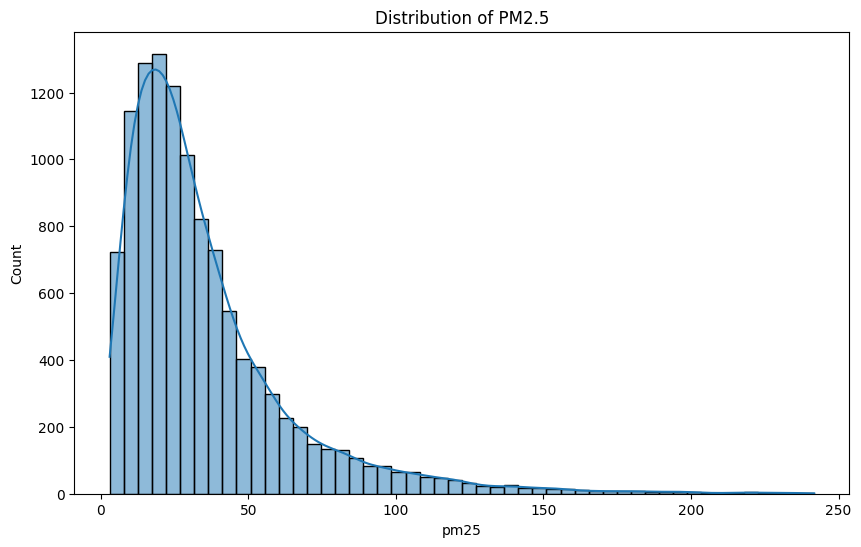

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(df['pm25'], bins=50, kde=True)
plt.title('Distribution of PM2.5')

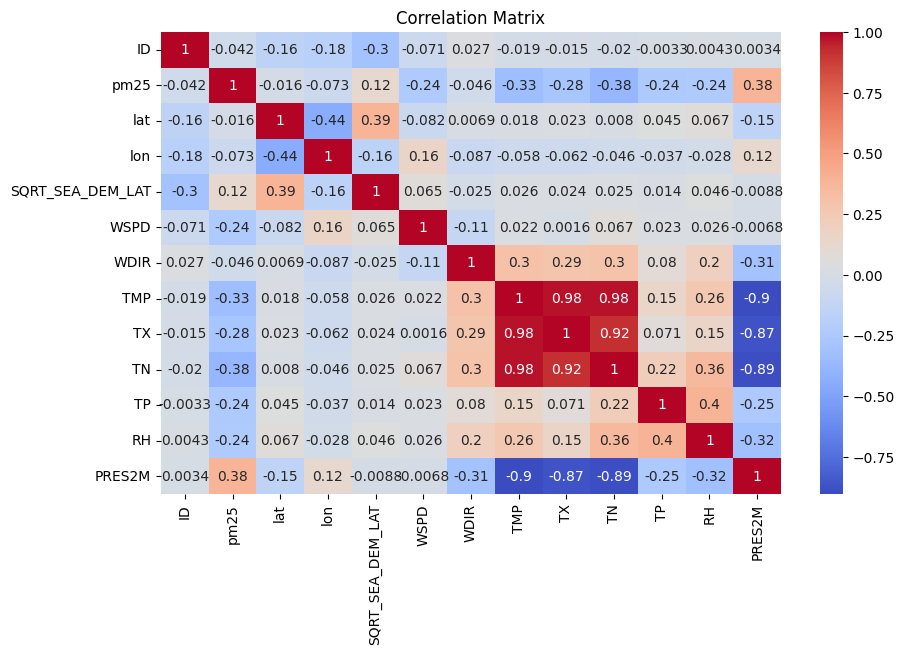

In [ ]:
plt.figure(figsize=(10, 6))

corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

TMP, TX, TN have high correlation score, because they are both temperature values.

pm25 does not perform high correlation with any features --> suggest that we should use non-linear learning model (I will choose LSTM)

# Select features

In [ ]:
features = ['SQRT_SEA_DEM_LAT', 'WSPD', 'WDIR', 'TMP', 'TX', 'TN', 'TP', 'RH', 'PRES2M']
target = 'pm25'

Normalize the features

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

df[features] = scaler_X.fit_transform(df[features])
df[target] = scaler_y.fit_transform(df[[target]])

In [ ]:
df.head()

,time,ID,pm25,lat,lon,SQRT_SEA_DEM_LAT,WSPD,WDIR,TMP,TX,TN,TP,RH,PRES2M
901,2020-02-26,5,0.216331,21.0213,105.8509,0.447359,0.317364,0.400121,0.533732,0.519049,0.503386,0.000000,0.637552,0.650313
957,2020-02-29,5,0.095300,21.0213,105.8509,0.447359,0.424038,0.402830,0.578218,0.547053,0.595681,0.005858,0.691318,0.536923
975,2020-03-01,5,0.107300,21.0213,105.8509,0.447359,0.316869,0.382342,0.587253,0.524260,0.609229,0.004687,0.723924,0.534510
993,2020-03-02,5,0.079110,21.0213,105.8509,0.447359,0.470865,0.380591,0.593342,0.517096,0.662574,0.003515,0.688369,0.554527
1011,2020-03-03,5,0.045297,21.0213,105.8509,0.447359,0.460172,0.420195,0.592016,0.520351,0.647756,0.022847,0.697041,0.558543


# Create input sequence for LSTM

suppose that we use 7 previous days data to predict today data

In [ ]:
!pip install torch

In [ ]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

In [ ]:
class SequenceDataset(Dataset):
  def __init__(self, data, sequence_length=7):
    self.X = []
    self.y = []
    grouped = data.groupby('ID')
    for _, group in grouped:
      group = group.sort_values('time')
      values = group[features + [target]].values
      for i in range(sequence_length, len(values)):
        self.X.append(values[i-sequence_length:i, :-1])
        self.y.append(values[i, -1])
    self.X = torch.tensor(self.X, dtype=torch.float32)
    self.y = torch.tensor(self.y, dtype=torch.float32).view(-1, 1)

  def __len__(self):
    return len(self.X)

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]

In [ ]:
sequence_length = 7
dataset = SequenceDataset(df, sequence_length)

<ipython-input-18-1c8043ae88cc>:12: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  self.X = torch.tensor(self.X, dtype=torch.float32)


# Split the dataset

In [ ]:
train_size = int(0.8 * len(dataset))
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, len(dataset) - train_size])
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Build the model

In [ ]:
class LSTM_Model(nn.Module):
  def __init__(self, input_size, hidden_size, num_layers):
    super(LSTM_Model, self).__init__()
    self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
    self.fc = nn.Sequential(
        nn.Linear(hidden_size, 32),
        nn.ReLU(),
        nn.Linear(32, 1)
    )

  def forward(self, x):
    out, _ = self.lstm(x)
    out = out[:, -1, :]
    return self.fc(out)

In [ ]:
input_size = len(features)
model = LSTM_Model(input_size=input_size, hidden_size=64, num_layers=2)

# Train the model

In [ ]:
import torch.optim as optim

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

LSTM_Model(
  (lstm): LSTM(9, 64, num_layers=2, batch_first=True)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [ ]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
for epoch in range(30):
  model.train()
  train_loss = 0
  for X_batch, y_batch in train_loader:
    X_batch, y_batch = X_batch.to(device), y_batch.to(device)
    optimizer.zero_grad()
    y_pred = model(X_batch)
    loss = criterion(y_pred, y_batch)
    loss.backward()
    optimizer.step()
    train_loss += loss.item()
  print(f"Epoch {epoch+1}, Loss: {train_loss / len(train_loader):.4f}")

Epoch 1, Loss: 0.0111
Epoch 2, Loss: 0.0098
Epoch 3, Loss: 0.0091
Epoch 4, Loss: 0.0086
Epoch 5, Loss: 0.0083
Epoch 6, Loss: 0.0082
Epoch 7, Loss: 0.0081
Epoch 8, Loss: 0.0081
Epoch 9, Loss: 0.0079
Epoch 10, Loss: 0.0077
Epoch 11, Loss: 0.0076
Epoch 12, Loss: 0.0077
Epoch 13, Loss: 0.0073
Epoch 14, Loss: 0.0072
Epoch 15, Loss: 0.0071
Epoch 16, Loss: 0.0070
Epoch 17, Loss: 0.0070
Epoch 18, Loss: 0.0070
Epoch 19, Loss: 0.0065
Epoch 20, Loss: 0.0066
Epoch 21, Loss: 0.0064
Epoch 22, Loss: 0.0063
Epoch 23, Loss: 0.0062
Epoch 24, Loss: 0.0062
Epoch 25, Loss: 0.0061
Epoch 26, Loss: 0.0060
Epoch 27, Loss: 0.0059
Epoch 28, Loss: 0.0057
Epoch 29, Loss: 0.0057
Epoch 30, Loss: 0.0056


# Evaluate the model

In [ ]:
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        y_pred.extend(outputs.cpu().numpy())
        y_true.extend(y_batch.numpy())

y_true_inv = scaler_y.inverse_transform(np.array(y_true).reshape(-1, 1))
y_pred_inv = scaler_y.inverse_transform(np.array(y_pred).reshape(-1, 1))

from sklearn.metrics import mean_squared_error, r2_score
rmse = np.sqrt(mean_squared_error(y_true_inv, y_pred_inv))
r2 = r2_score(y_true_inv, y_pred_inv)

print(f"RMSE: {rmse:.2f}, R2: {r2:.2f}")

RMSE: 18.92, R2: 0.59


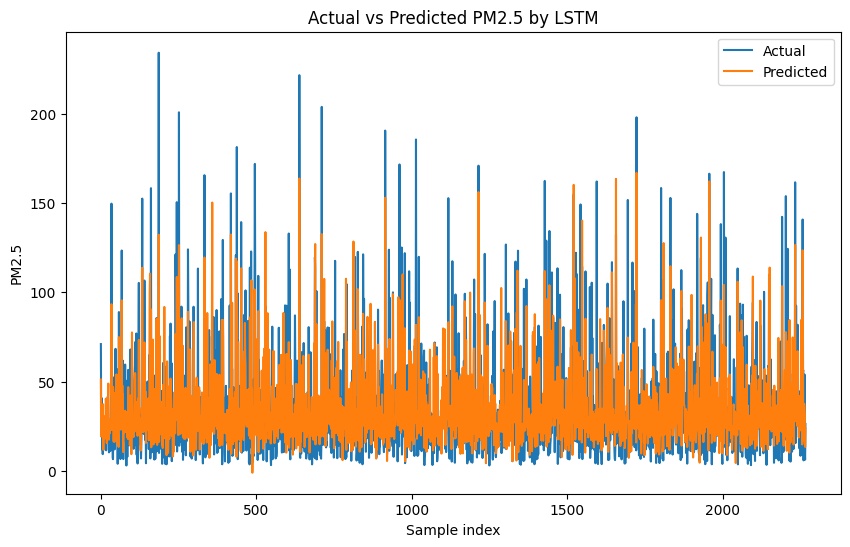

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(y_true_inv, label='Actual')
plt.plot(y_pred_inv, label='Predicted')
plt.title('Actual vs Predicted PM2.5 by LSTM')
plt.xlabel('Sample index')
plt.ylabel('PM2.5')
plt.legend()
plt.show()